In [8]:
import pandas as pd
print("Ready!")


Ready!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [10]:
df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\Project Portfolio\IBM HR Attrition Analysis\WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
df.head()


(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [12]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [13]:
# Drop columns that add no analytical value
df = df.drop(columns=["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"])

print(f"Remaining columns: {df.shape[1]}")

Remaining columns: 31


In [14]:
df["Attrition_Num"] = (df["Attrition"] == "Yes").astype(int)
print(df["Attrition_Num"].value_counts())

Attrition_Num
0    1233
1     237
Name: count, dtype: int64


In [15]:

print(df.duplicated().sum())

0


In [16]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBalance                4
YearsAtCompany                37
YearsInCurrentRole            19
YearsSinceLastPromotion       16
YearsWithC

In [17]:

df.shape

(1470, 32)

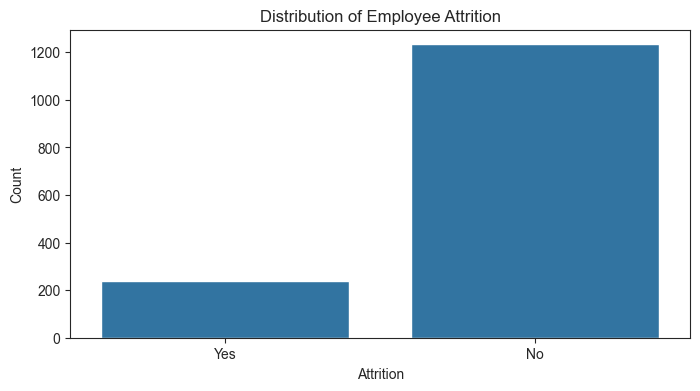

In [18]:
sns.set_style("ticks")
plt.rcParams["figure.figsize"] = (8, 4)
sns.countplot(x="Attrition", data=df)
plt.title("Distribution of Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

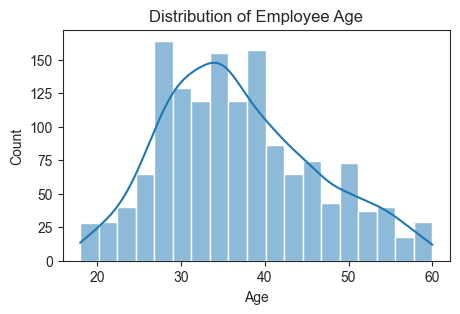

In [19]:
sns.set_style("ticks")
plt.rcParams["figure.figsize"] = (5, 3)
sns.histplot(data=df["Age"], kde =True)
plt.title("Distribution of Employee Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

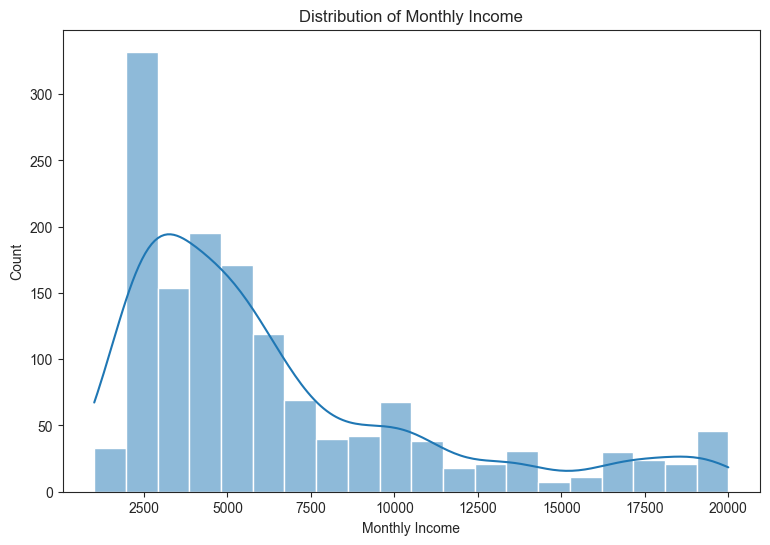

In [20]:
plt.rcParams["figure.figsize"] = (9, 6)
sns.histplot(data=df["MonthlyIncome"], kde =True)
sns.set_style("ticks")
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.show()

In [21]:
attrition_rate = df["Attrition_Num"].mean() * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


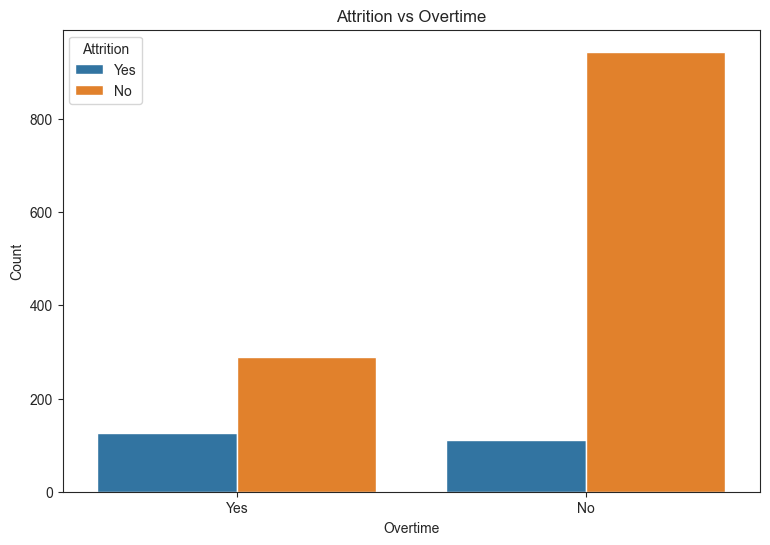

In [29]:
sns.countplot(x="OverTime", hue="Attrition", data=df, order=["Yes", "No"])
plt.title("Attrition vs Overtime")
plt.legend(title="Attrition")
plt.xlabel("Overtime")
plt.ylabel("Count")
plt.show()

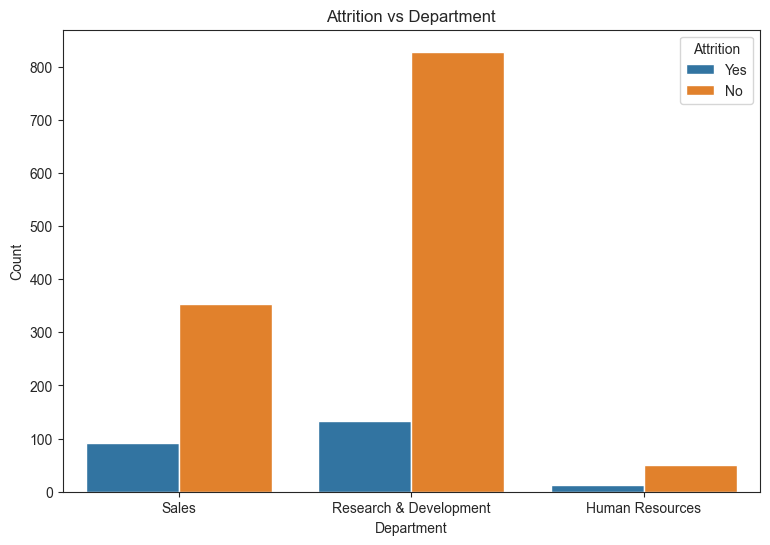

In [23]:
sns.countplot(x="Department", hue="Attrition", data=df, order=["Sales", "Research & Development", "Human Resources"])
plt.title("Attrition vs Department")
plt.legend(title="Attrition")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

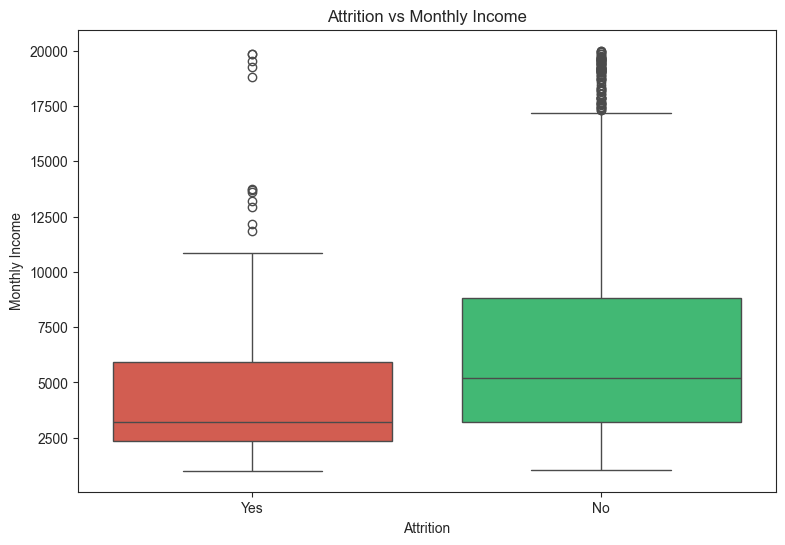

In [24]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, hue="Attrition", palette=["#e74c3c", "#2ecc71"], legend=False)
plt.title("Attrition vs Monthly Income")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

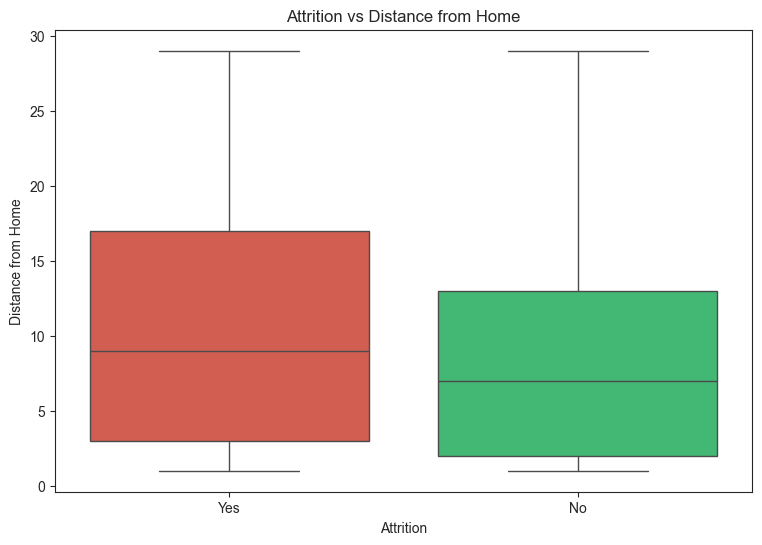

In [26]:
sns.boxplot(x="Attrition", y="DistanceFromHome", data=df, hue="Attrition", palette=["#e74c3c", "#2ecc71"], legend=False)
plt.title("Attrition vs Distance from Home")
plt.xlabel("Attrition")
plt.ylabel("Distance from Home")
plt.show()

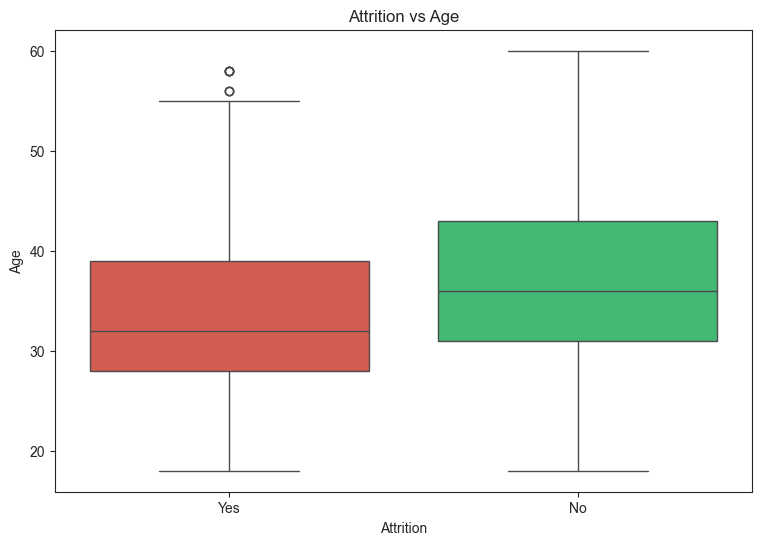

In [27]:
sns.boxplot(x="Attrition", y="Age", data=df, hue="Attrition", palette=["#e74c3c", "#2ecc71"], legend=False)
plt.title("Attrition vs Age")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

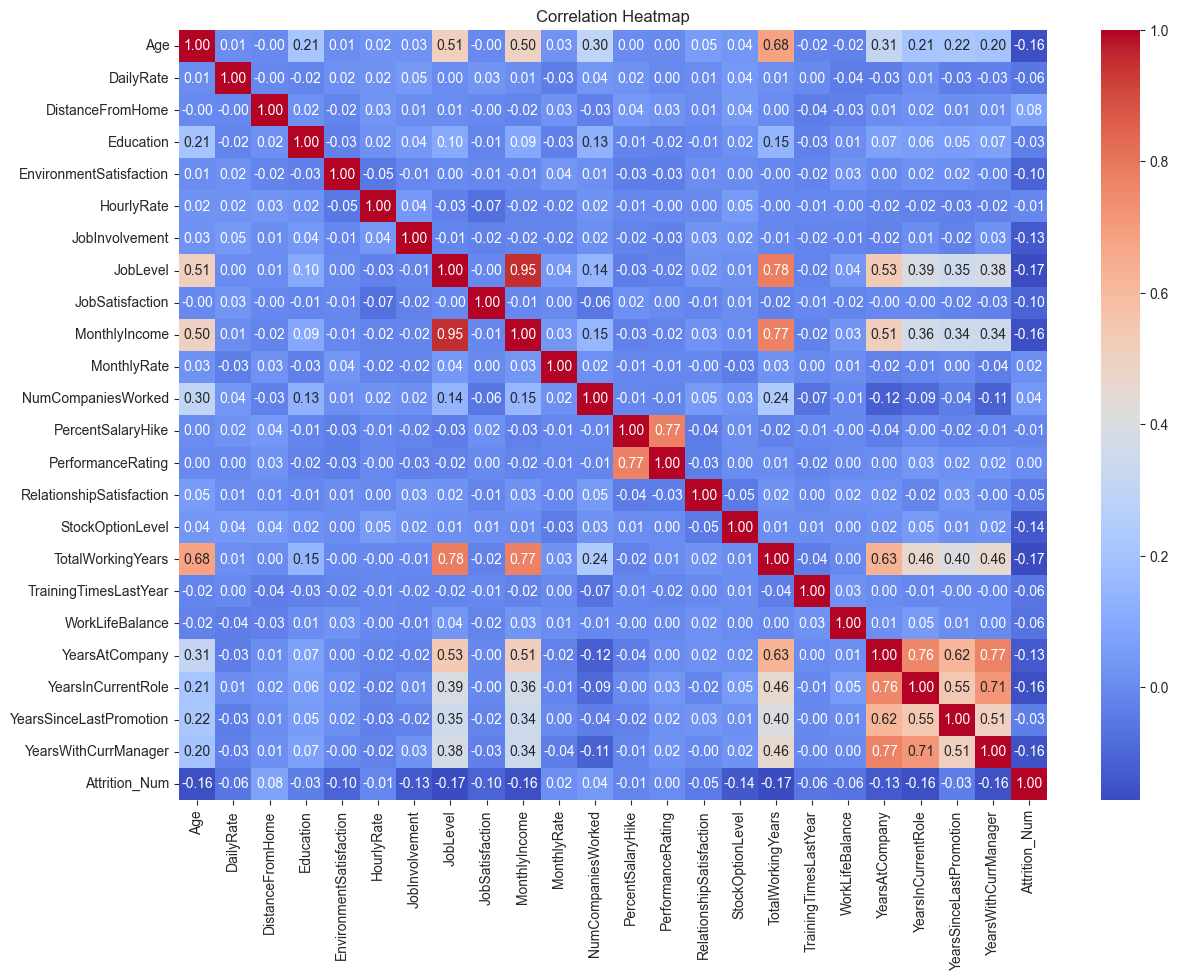

In [28]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [30]:
print(df.groupby("OverTime")["Attrition_Num"].mean() * 100)
print(df.groupby("Attrition")["MonthlyIncome"].median())
print(df.groupby("Department")["Attrition_Num"].mean() * 100)

OverTime
No     10.436433
Yes    30.528846
Name: Attrition_Num, dtype: float64
Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64
Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition_Num, dtype: float64


## Key Findings

1. The overall attrition rate is 16.12% , meaning 16 out of every 100 employees left the company, total of 237 out of 1,470 employees left the company.
2. Employees who worked overtime were significantly more likely to leave, overtime workers had a 30.5% attrition rate compared to just 10.4% for non-overtime workers, suggesting burnout and work-life imbalance are key drivers of attrition.
3. Employees who left earned a lower median monthly income compared to those who stayed ($3,202 vs $5,204), indicating that compensation is a strong retention factor (correlation: -0.16).
4. The Sales Department showed the highest attrition among all departments (20.6%), nearly double that of R&D (13.8%), which may be linked to high-pressure targets and workload.
5. Interestingly, Performance Rating showed a near-zero correlation (0.00) with attrition, suggesting that whether an employee leaves has little to do with how well they perform — high and low performers leave at similar rates.